<a href="https://colab.research.google.com/github/umraodeepika7-dotcom/ctgan/blob/main/SDV_Synthesize_a_table_(Gaussian_Copula).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[SDV Docs](https://docs.sdv.dev/sdv) > [Tutorials](https://docs.sdv.dev/sdv/tutorials)

# Synthesize a Table (Gaussian Coupla)

In this notebook, we'll use the SDV to create synthetic data for a single table and evaluate it. The SDV uses machine learning to learn patterns from real data and emulates them when creating synthetic data.

We'll use the **Gaussian Copula** algorithm to do this. Gaussian Copula is a fast, customizable and transparent way to synthesize data.

_Last Edit: January 30, 2026_

# 0. Installation

Install SDV Community.

In [2]:
%pip install sdv

In [1]:
!pip install table_evaluator

In [3]:
!pip install dython

  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
^C


# 1. Loading the demo data
For this demo, we'll use a fake dataset that describes some fictional guests staying at a hotel.

In [3]:
from google.colab import files
uploaded = files.upload()


Saving Pretreatment RS.csv to Pretreatment RS.csv


In [6]:
import pandas as pd
data = pd.read_csv('Pretreatment RS.csv')

In [7]:
real_data = pd.read_csv('Pretreatment RS.csv')

In [8]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=real_data)

In [9]:
display(real_data.head())

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,H2O,Original,0.60,0.00,0.61,1.25,1.00,3.17,0.30,0.00,0.88,0.00,0.09,31.67
1,H2O,Treated,0.68,0.00,0.58,1.07,0.94,2.66,0.24,0.00,0.92,0.00,0.00,22.24
2,H2SO4,Original,10.81,2.49,2.55,1.63,3.81,36.70,1.06,0.00,7.65,0.03,0.39,69.84
3,H2SO4,Treated,10.70,0.00,1.89,1.72,4.09,31.10,0.38,0.00,1.31,0.00,0.04,44.40
4,HCl,Original,37.26,4.55,0.66,11.18,5.97,66.37,1.83,0.28,5.46,0.00,0.16,74.64


In [10]:
categorical_features = ['Catalyst', 'samples', 'Xyl','Fur','Glu','Cel','Ara.','Total RS','EtOH','BuOH','Ace.','Prop.','n-But.','COD']

The demo also includes **metadata**, a description of the dataset. It includes the primary keys as well as the data types for each column (called "sdtypes").

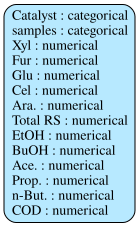

In [11]:
metadata.visualize()

In [16]:
from ctgan import CTGAN
import pandas as pd # Import pandas
ctgan = CTGAN(verbose=True)
ctgan.fit(real_data, categorical_features, epochs=80)

Gen. (+01.58) | Discrim. (-00.12): 100%|██████████| 80/80 [00:09<00:00,  8.64it/s]


# 2. Basic Usage

## 2.1 Creating a Synthesizer

An SDV **synthesizer** is an object that you can use to create synthetic data. It learns patterns from the real data and replicates them to generate synthetic data.

In [17]:
from sdv.single_table import GaussianCopulaSynthesizer

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(real_data)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


Now the synthesizer is ready to use!

## 2.2 Generating Synthetic Data

Use the `sample` function and pass in any number of rows to synthesize.

In [18]:
synthetic_data = synthesizer.sample(num_rows=500)
synthetic_data.head()

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,HCl,Original,29.38,3.95,2.55,7.26,5.36,63.29,1.34,0.0,7.59,0.0,0.37,65.09
1,HCl,Treated,12.34,0.01,1.26,4.56,2.05,27.90,0.49,0.0,4.85,0.0,0.32,34.85
2,HNO3,Original,25.99,0.01,0.59,7.90,6.73,62.12,0.94,0.0,1.13,0.0,0.07,77.07
3,H2SO4,Original,6.45,0.17,2.55,2.32,2.89,10.53,1.02,0.0,7.62,0.0,0.37,45.49
4,H2O,Original,7.77,0.10,0.36,3.39,5.74,5.99,0.27,0.0,0.70,0.0,0.04,73.92


In [21]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(synthetic_data)

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,HCl,Original,29.38,3.95,2.55,7.26,5.36,63.29,1.34,0.00,7.59,0.00,0.37,65.09
1,HCl,Treated,12.34,0.01,1.26,4.56,2.05,27.90,0.49,0.00,4.85,0.00,0.32,34.85
2,HNO3,Original,25.99,0.01,0.59,7.90,6.73,62.12,0.94,0.00,1.13,0.00,0.07,77.07
3,H2SO4,Original,6.45,0.17,2.55,2.32,2.89,10.53,1.02,0.00,7.62,0.00,0.37,45.49
4,H2O,Original,7.77,0.10,0.36,3.39,5.74,5.99,0.27,0.00,0.70,0.00,0.04,73.92
5,H2O,Treated,3.76,0.00,0.36,2.85,5.67,19.29,0.36,0.00,0.55,0.00,0.20,70.77
6,HCl,Treated,5.73,0.00,1.20,2.31,1.75,4.61,0.30,0.00,3.69,0.00,0.22,30.17
7,H2O,Original,1.94,0.00,0.38,2.95,6.15,13.64,0.38,0.00,1.07,0.00,0.24,80.12
8,H2SO4,Original,29.88,4.50,1.96,9.55,6.73,65.99,1.12,0.28,7.20,0.00,0.37,82.72
9,H2SO4,Original,23.65,2.43,0.42,9.45,3.20,63.89,1.07,0.28,1.28,0.00,0.10,50.74


The synthesizer is generating synthetic guests in the **same format as the original data**.

## 2.3 Evaluating Real vs. Synthetic Data

SDV has built-in functions for evaluating the synthetic data and getting more insight.

As a first step, we can run a **diagnostic** to ensure that the data is valid. SDV's diagnostic performs some basic checks such as:

- All primary keys must be unique
- Continuous values must adhere to the min/max of the real data
- Discrete columns (non-PII) must have the same categories as the real data
- Etc.

In [22]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 14/14 [00:00<00:00, 632.50it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 165.91it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



<font color="green"><b>The score is 100%</b></font>, indicating that the data is fully valid.

We can also measure the **data quality** or the statistical similarity between the real and synthetic data. This value may vary anywhere from 0 to 100%.

In [23]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 725.04it/s]|
Column Shapes Score: 75.64%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:00<00:00, 163.95it/s]|
Column Pair Trends Score: 64.87%

Overall Score (Average): 70.25%



The score tells us how similar the synthetic data is to the real data in terms of statistical patterns.

We can also get more details from the report. For example, the Column Shapes sub-score: Which columns had the highest vs. the lowest scores?

In [24]:
quality_report.get_details('Column Shapes')

,Column,Metric,Score
0,Catalyst,TVComplement,0.916
1,samples,TVComplement,0.928
2,Xyl,KSComplement,0.688
3,Fur,KSComplement,0.607
4,Glu,KSComplement,0.761
5,Cel,KSComplement,0.584
6,Ara.,KSComplement,0.760
7,Total RS,KSComplement,0.796
8,EtOH,KSComplement,0.770
9,BuOH,KSComplement,0.987


## 2.4 Visualizing the Data
For more insights, we can visualize the real vs. synthetic data.

Let's perform a 1D visualization comparing a column of the real data to the synthetic data.

In [26]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    column_name='Total RS',
    metadata=metadata
)

fig.show()


In [27]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    column_name='Catalyst',
    metadata=metadata
)

fig.show()

### Detailed Quality Report: Column Shapes

In [30]:
quality_report.get_details('Column Shapes')

,Column,Metric,Score
0,Catalyst,TVComplement,0.916
1,samples,TVComplement,0.928
2,Xyl,KSComplement,0.688
3,Fur,KSComplement,0.607
4,Glu,KSComplement,0.761
5,Cel,KSComplement,0.584
6,Ara.,KSComplement,0.760
7,Total RS,KSComplement,0.796
8,EtOH,KSComplement,0.770
9,BuOH,KSComplement,0.987


### Detailed Quality Report: Column Pair Trends

In [31]:
quality_report.get_details('Column Pair Trends')

,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,Catalyst,samples,ContingencySimilarity,NaN,NaN,NaN,0.000000,False
1,Catalyst,Xyl,ContingencySimilarity,0.186000,NaN,NaN,1.000000,True
2,Catalyst,Fur,ContingencySimilarity,0.524000,NaN,NaN,0.632456,True
3,Catalyst,Glu,ContingencySimilarity,0.210000,NaN,NaN,0.781736,True
4,Catalyst,Cel,ContingencySimilarity,0.214000,NaN,NaN,0.707107,True
5,Catalyst,Ara.,ContingencySimilarity,0.206000,NaN,NaN,0.912871,True
6,Catalyst,Total RS,ContingencySimilarity,0.288000,NaN,NaN,0.881917,True
7,Catalyst,EtOH,ContingencySimilarity,0.272000,NaN,NaN,0.881917,True
8,Catalyst,BuOH,ContingencySimilarity,0.773000,NaN,NaN,0.654654,True
9,Catalyst,Ace.,ContingencySimilarity,0.136000,NaN,NaN,0.881917,True


In [29]:
from sdv.evaluation.single_table import evaluate_quality

quality_report_overall = evaluate_quality(
    real_data,
    synthetic_data,
    metadata
)

print(f"Overall Quality Score: {quality_report_overall.get_score():.2f}%")

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 171.18it/s]|
Column Shapes Score: 75.64%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:01<00:00, 63.30it/s]|
Column Pair Trends Score: 64.87%

Overall Score (Average): 70.25%

Overall Quality Score: 0.70%


We can also visualize in 2D, comparing the correlations of a pair of columns.

In [28]:
from sdv.evaluation.single_table import get_column_pair_plot

fig = get_column_pair_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    column_names=['Xyl', 'Total RS'],
    metadata=metadata
)

fig.show()

In [33]:
!pip install shap

In [34]:
!pip install numpy

### Calculate SHAP values for Real Data ('Total RS')

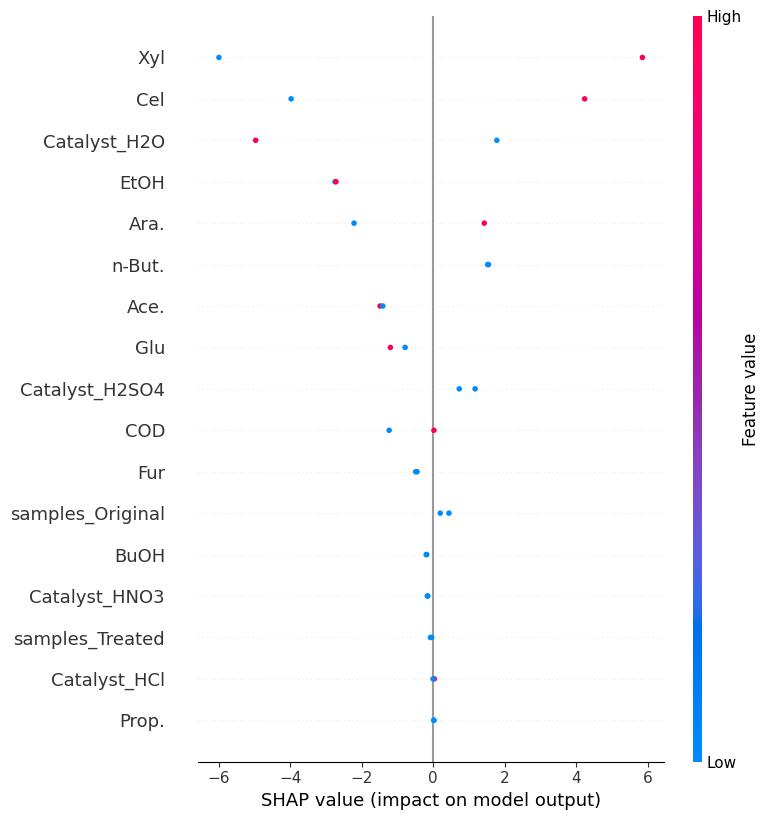

In [37]:
# Define features (X_real) and target (y_real) for real data
X_real = real_data.drop('Total RS', axis=1)
y_real = real_data['Total RS']

# Convert categorical features in X_real to numerical using one-hot encoding
X_real = pd.get_dummies(X_real, columns=['Catalyst', 'samples'])

# Split real data into training and testing sets
X_real_train, X_real_test, y_real_train, y_real_test = train_test_split(X_real, y_real, test_size=0.2, random_state=42)

# Train a RandomForestRegressor model on real data
model_real = RandomForestRegressor(n_estimators=100, random_state=42)
model_real.fit(X_real_train, y_real_train)

# Initialize SHAP explainer for the real data model
explainer_real = shap.TreeExplainer(model_real)

# Calculate SHAP values for the real test set
shap_values_real = explainer_real.shap_values(X_real_test)

# Visualize the SHAP values (summary plot) for real data
shap.summary_plot(shap_values_real, X_real_test)


This summary plot shows the importance of each feature in predicting 'Total RS' using the **real data**. You can now compare this with the previous SHAP summary plot generated using the **synthetic data** to see how well the synthetic data preserves feature importances.

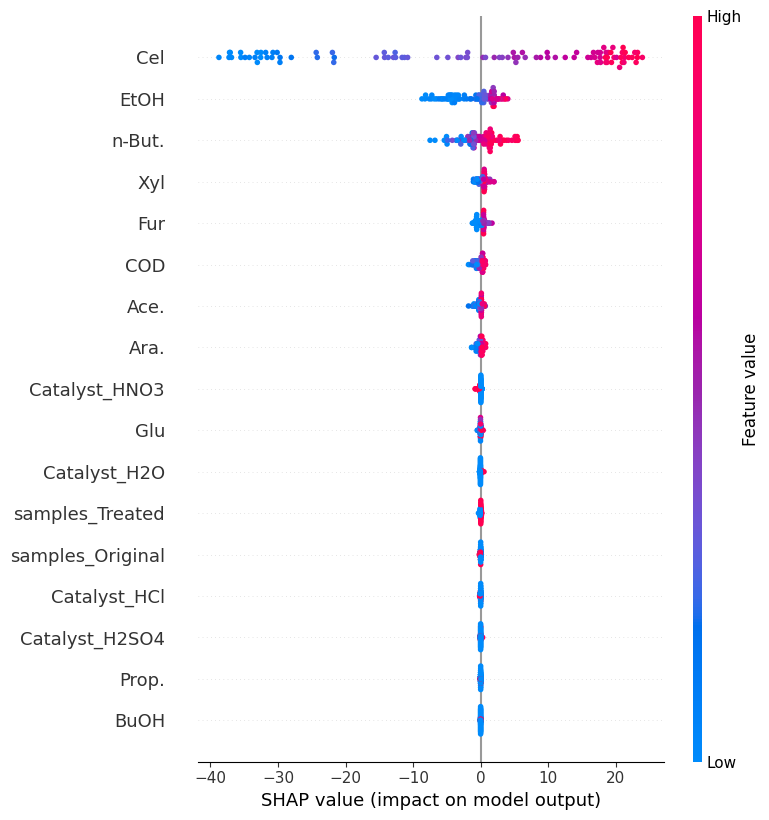

In [36]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import pandas as pd

# Define features (X) and new target (y)
X = synthetic_data.drop('Total RS', axis=1)
y = synthetic_data['Total RS']

# Convert categorical features in X to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['Catalyst', 'samples'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Visualize the SHAP values (summary plot)
shap.summary_plot(shap_values, X_test)


This summary plot shows the importance of each feature. Each point on the plot is a Shapley value for an instance and a feature. The position on the x-axis indicates the impact of that feature on the model's prediction. The color represents the feature's value (red for high, blue for low).

### Visualizing Real vs. Gaussian Mixture Synthetic Data Distributions

### Visualizing Real vs. Gaussian Copula Synthetic Data Distributions (closest SDV equivalent)

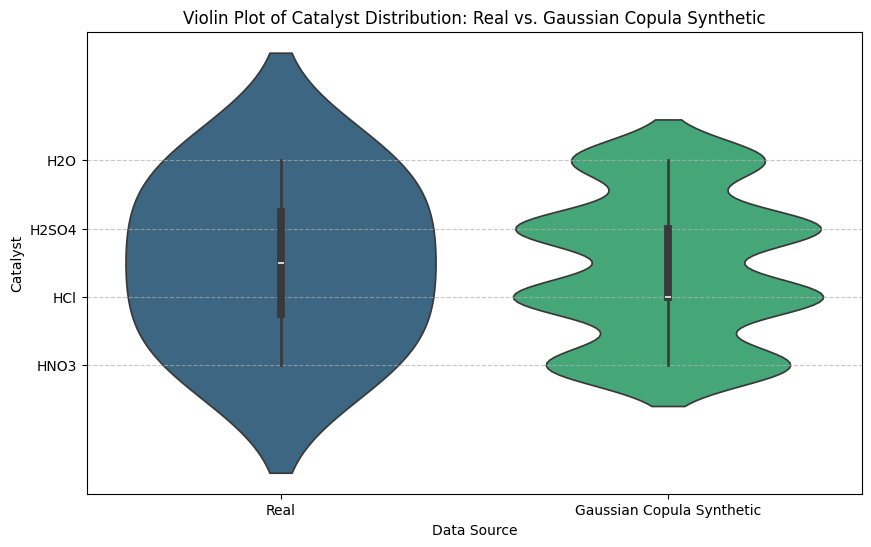

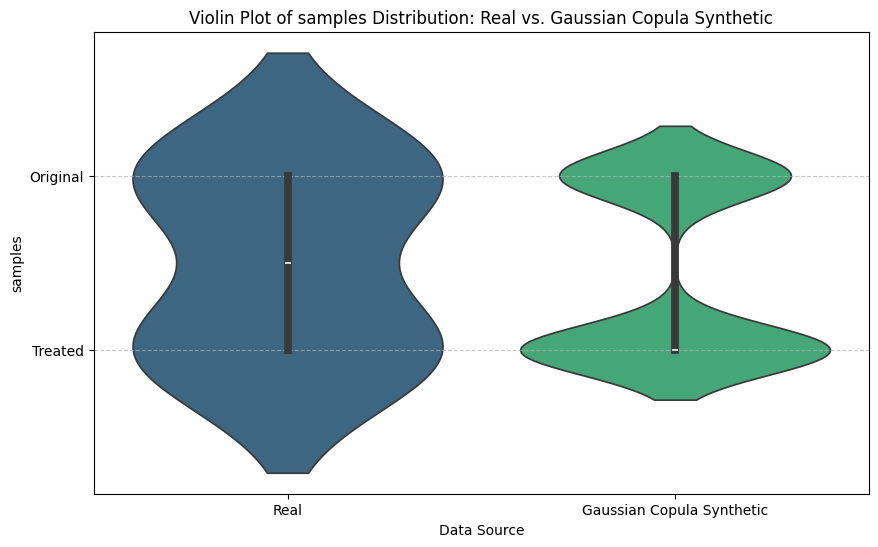

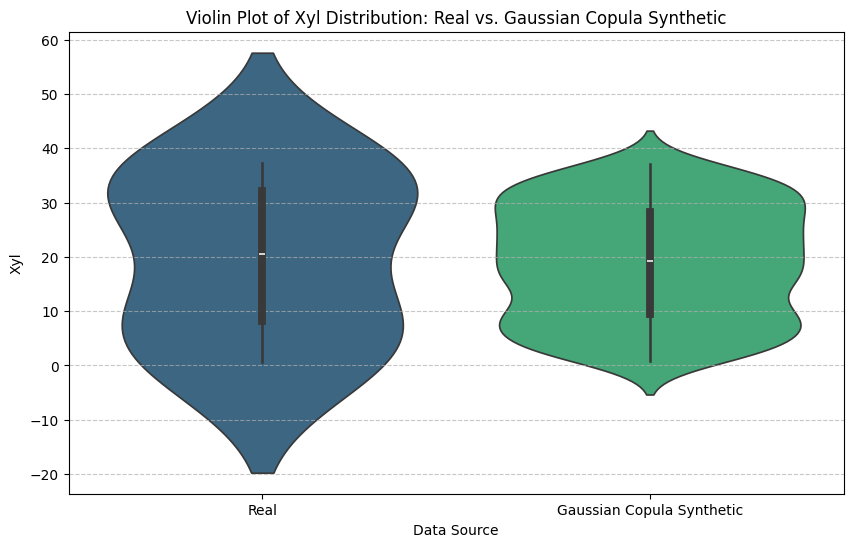

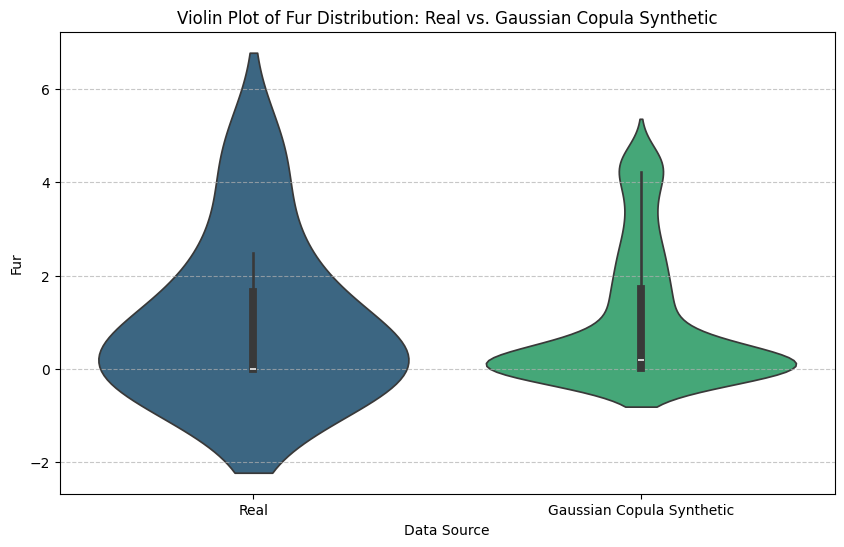

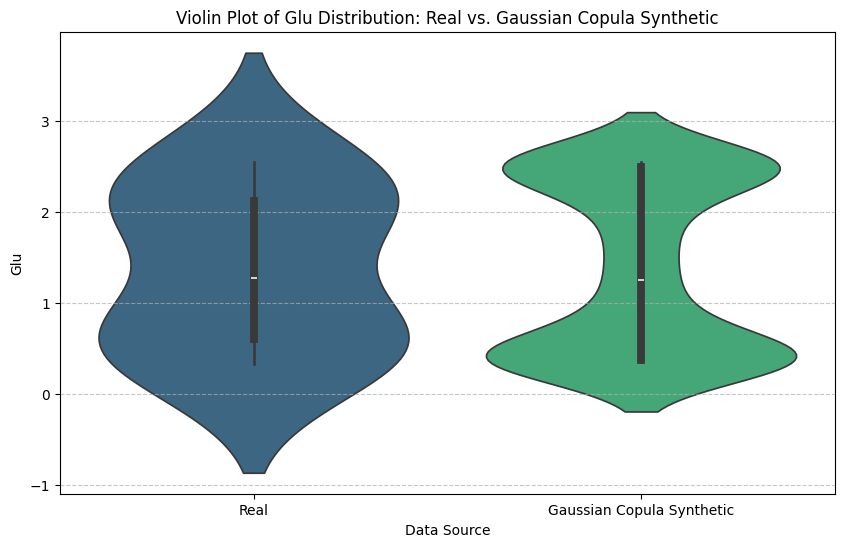

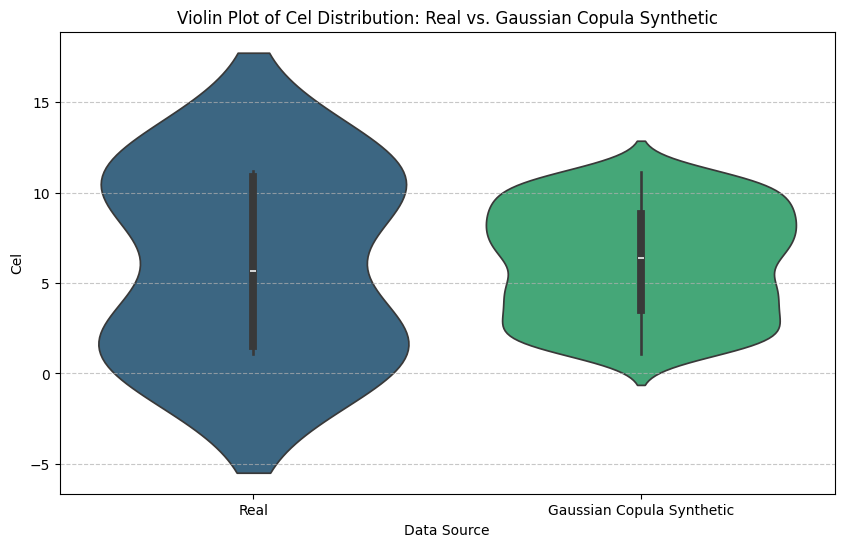

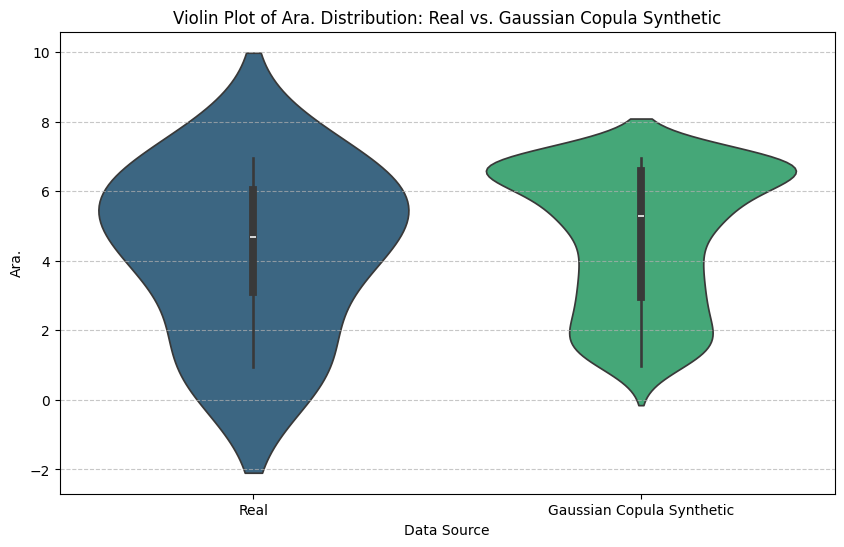

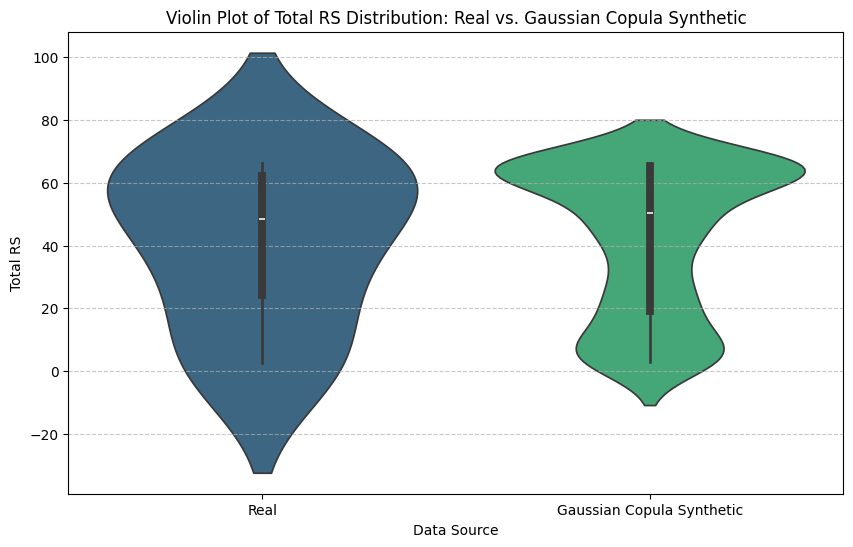

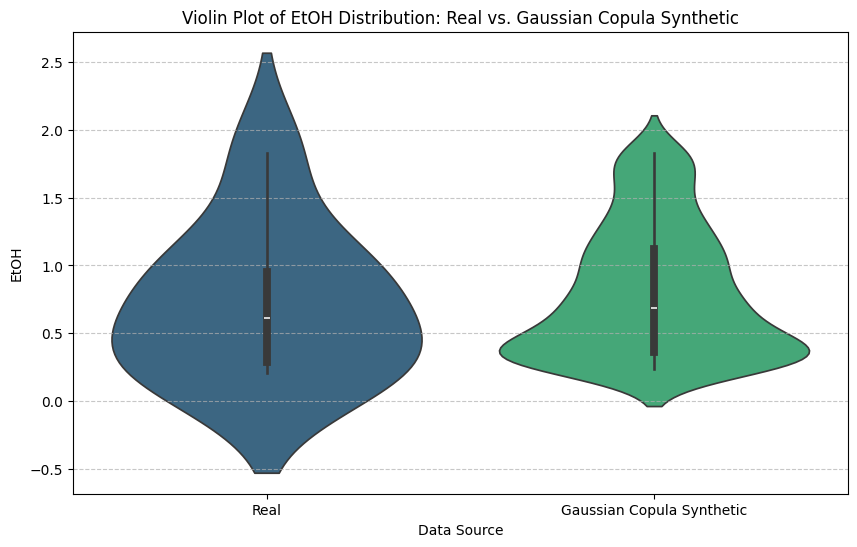

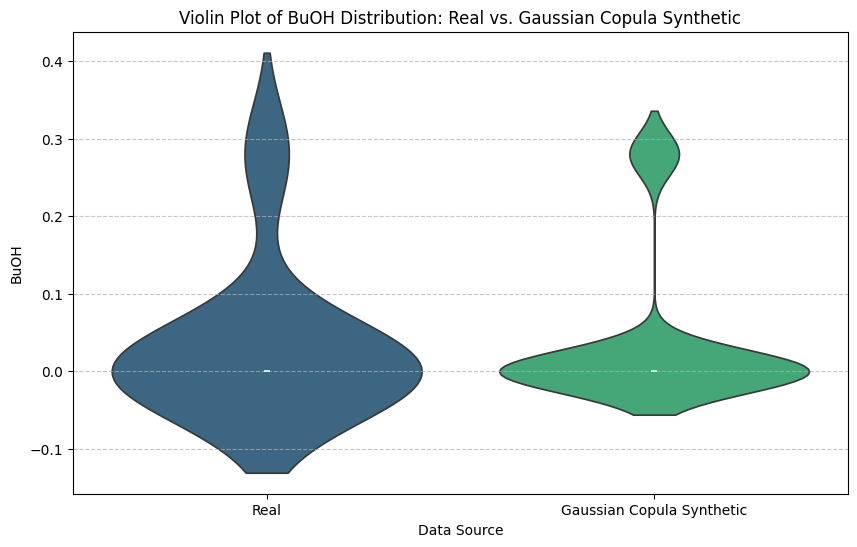

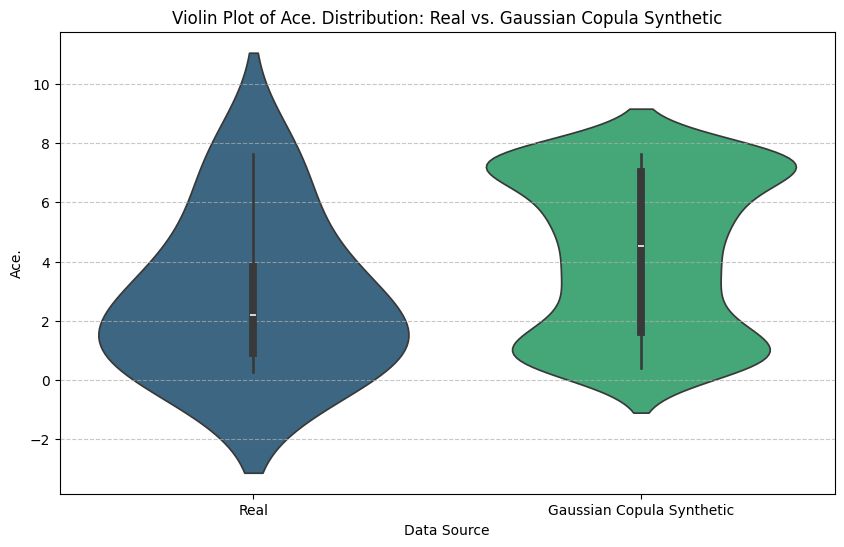

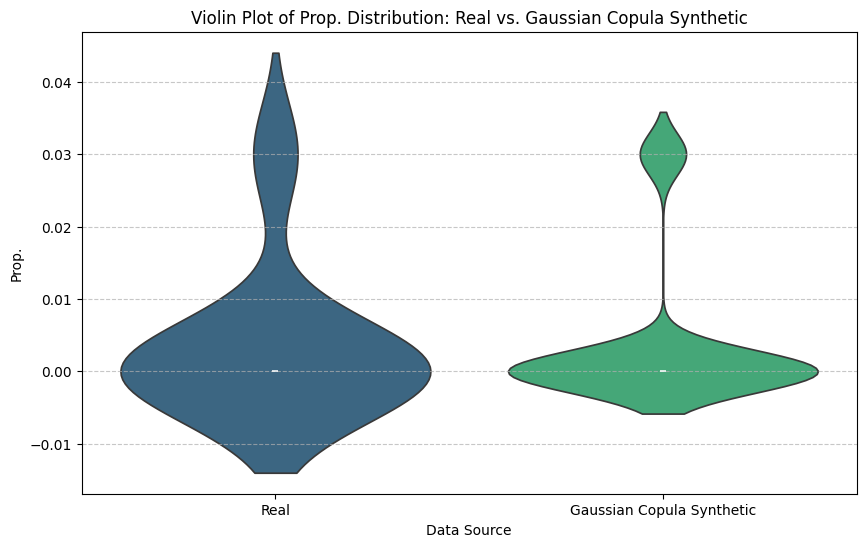

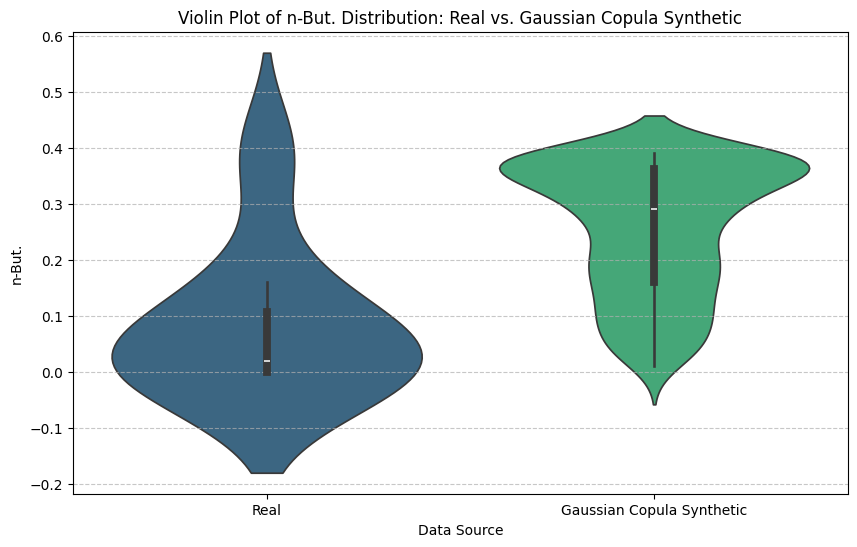

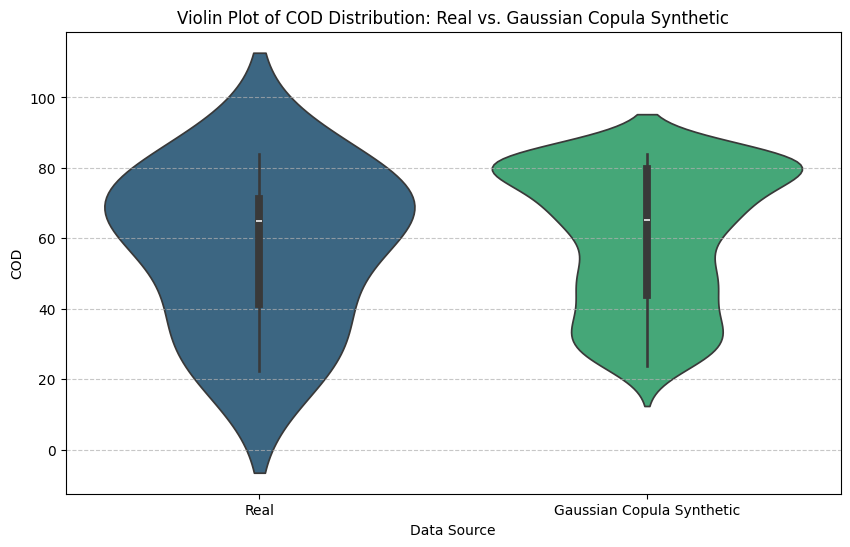

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# We will use the 'synthetic_data' already generated by the GaussianCopulaSynthesizer
# as it is the primary Gaussian-based statistical synthesizer in SDV.

# List of columns to plot (using all columns from real_data for comparison)
columns_to_plot = real_data.columns.tolist()

for column in columns_to_plot:
    # Create a combined DataFrame for the current column
    df_combined = pd.DataFrame({
        column: real_data[column],
        'Source': 'Real'
    })
    df_combined = pd.concat([
        df_combined,
        pd.DataFrame({
            column: synthetic_data[column],
            'Source': 'Gaussian Copula Synthetic'
        })
    ])

    # Create the violin plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Source', y=column, data=df_combined, hue='Source', palette='viridis', legend=False)
    plt.title(f'Violin Plot of {column} Distribution: Real vs. Gaussian Copula Synthetic')
    plt.xlabel('Data Source')
    plt.ylabel(column)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

### Skewness and Kurtosis Analysis

In [46]:
# Calculate Skewness for Real Data
print('Skewness for Real Data:')
display(real_data.skew(numeric_only=True))

# Calculate Kurtosis for Real Data
print('\nKurtosis for Real Data:')
display(real_data.kurt(numeric_only=True))

Skewness for Real Data:


,0
Xyl,-0.150506
Fur,1.586150
Glu,0.115574
Cel,0.023616
Ara.,-0.641738
Total RS,-0.636777
EtOH,1.140242
BuOH,2.828427
Ace.,1.028012
Prop.,2.828427



Kurtosis for Real Data:


,0
Xyl,-2.167758
Fur,1.872092
Glu,-2.329010
Cel,-2.725239
Ara.,-1.023359
Total RS,-1.401424
EtOH,1.042130
BuOH,8.000000
Ace.,0.161078
Prop.,8.000000


In [47]:
# Calculate Skewness for Synthetic Data
print('Skewness for Synthetic Data:')
display(synthetic_data.skew(numeric_only=True))

# Calculate Kurtosis for Synthetic Data
print('\nKurtosis for Synthetic Data:')
display(synthetic_data.kurt(numeric_only=True))

Skewness for Synthetic Data:


,0
Xyl,-0.028255
Fur,1.295981
Glu,0.096612
Cel,-0.057048
Ara.,-0.460070
Total RS,-0.505398
EtOH,0.693486
BuOH,2.105481
Ace.,-0.130543
Prop.,2.207020



Kurtosis for Synthetic Data:


,0
Xyl,-1.208470
Fur,0.361883
Glu,-1.780097
Cel,-1.230830
Ara.,-1.228581
Total RS,-1.343706
EtOH,-0.676400
BuOH,2.442805
Ace.,-1.518061
Prop.,2.882453


#### Interpretation:
- **Skewness** measures the asymmetry of the probability distribution of a real-valued random variable about its mean. A positive skewness indicates a distribution with an asymmetric tail extending toward more positive values, while a negative skewness indicates a distribution with an asymmetric tail extending toward more negative values.
- **Kurtosis** measures the 'tailedness' of the probability distribution of a real-valued random variable. High kurtosis indicates a distribution with heavy tails (more outliers), and low kurtosis indicates a distribution with light tails (fewer outliers).

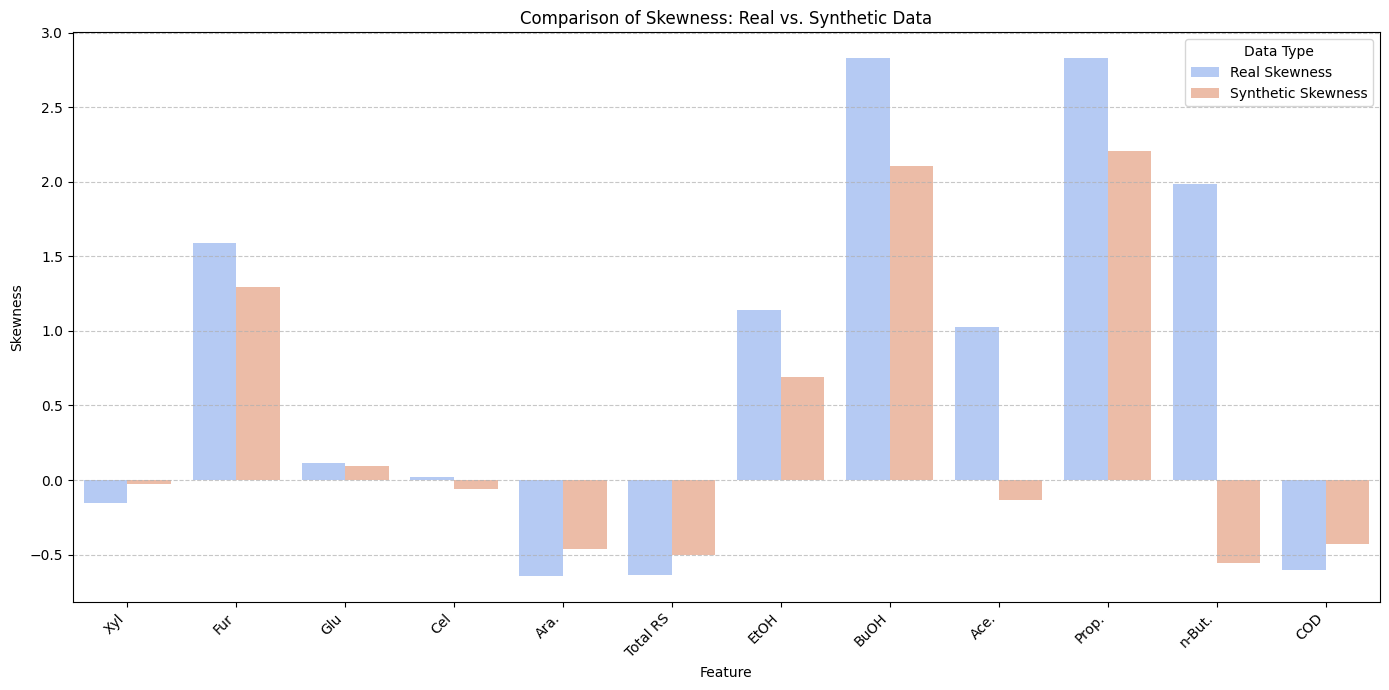

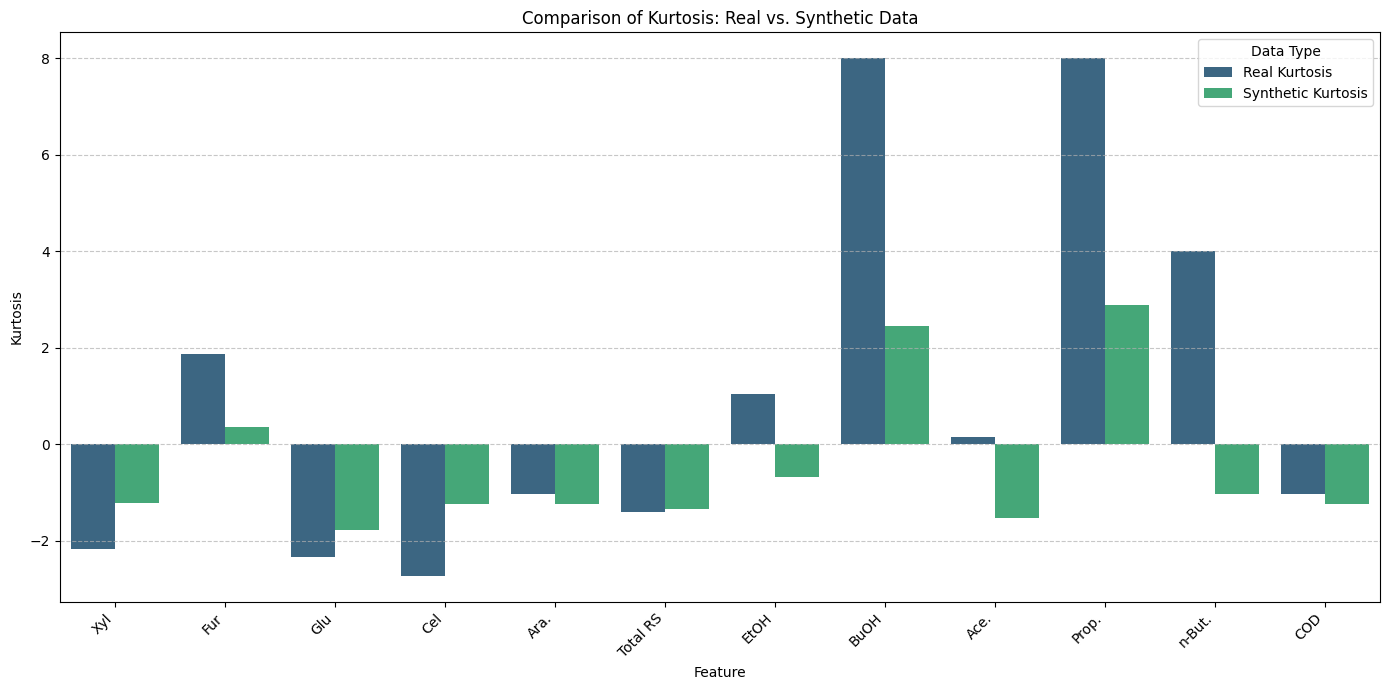

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Skewness and Kurtosis for Real and Synthetic Data
skew_real = real_data.skew(numeric_only=True)
kurt_real = real_data.kurt(numeric_only=True)
skew_synthetic = synthetic_data.skew(numeric_only=True)
kurt_synthetic = synthetic_data.kurt(numeric_only=True)

# Combine into DataFrames for plotting
skew_df = pd.DataFrame({
    'Feature': skew_real.index,
    'Real Skewness': skew_real.values,
    'Synthetic Skewness': skew_synthetic.values
})

kurt_df = pd.DataFrame({
    'Feature': kurt_real.index,
    'Real Kurtosis': kurt_real.values,
    'Synthetic Kurtosis': kurt_synthetic.values
})

# Melt DataFrames for seaborn plotting
skew_melted = skew_df.melt(id_vars='Feature', var_name='Data Type', value_name='Skewness')
kurt_melted = kurt_df.melt(id_vars='Feature', var_name='Data Type', value_name='Kurtosis')

# Plot Skewness
plt.figure(figsize=(14, 7))
sns.barplot(x='Feature', y='Skewness', hue='Data Type', data=skew_melted, palette='coolwarm')
plt.title('Comparison of Skewness: Real vs. Synthetic Data')
plt.xlabel('Feature')
plt.ylabel('Skewness')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot Kurtosis
plt.figure(figsize=(14, 7))
sns.barplot(x='Feature', y='Kurtosis', hue='Data Type', data=kurt_melted, palette='viridis')
plt.title('Comparison of Kurtosis: Real vs. Synthetic Data')
plt.xlabel('Feature')
plt.ylabel('Kurtosis')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparison of Testing Performance: Real vs. Synthetic Data (R2, RMSE, MAE)

In [50]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# --- Metrics for Real Data ---
# Make predictions on the real test set using the model trained on real data
y_real_pred = model_real.predict(X_real_test)

# Calculate R2, RMSE, MAE for real data
r2_real = r2_score(y_real_test, y_real_pred)
rmse_real = np.sqrt(mean_squared_error(y_real_test, y_real_pred))
mae_real = mean_absolute_error(y_real_test, y_real_pred)

print("Performance Metrics for Real Data:")
print(f"  R2 Score: {r2_real:.4f}")
print(f"  RMSE: {rmse_real:.4f}")
print(f"  MAE: {mae_real:.4f}")

# --- Metrics for Synthetic Data ---
# Make predictions on the synthetic test set using the model trained on synthetic data
y_synthetic_pred = model.predict(X_test)

# Calculate R2, RMSE, MAE for synthetic data
r2_synthetic = r2_score(y_test, y_synthetic_pred)
rmse_synthetic = np.sqrt(mean_squared_error(y_test, y_synthetic_pred))
mae_synthetic = mean_absolute_error(y_test, y_synthetic_pred)

print("\nPerformance Metrics for Synthetic Data:")
print(f"  R2 Score: {r2_synthetic:.4f}")
print(f"  RMSE: {rmse_synthetic:.4f}")
print(f"  MAE: {mae_synthetic:.4f}")

# --- Comparison Table (for better visualization) ---
metrics_data = {
    'Metric': ['R2 Score', 'RMSE', 'MAE'],
    'Real Data': [r2_real, rmse_real, mae_real],
    'Synthetic Data': [r2_synthetic, rmse_synthetic, mae_synthetic]
}
metrics_df = pd.DataFrame(metrics_data)

print("\nComparison Table:")
display(metrics_df)

Performance Metrics for Real Data:
  R2 Score: 0.7722
  RMSE: 13.6826
  MAE: 12.4688

Performance Metrics for Synthetic Data:
  R2 Score: 0.9420
  RMSE: 5.7539
  MAE: 3.7209

Comparison Table:


,Metric,Real Data,Synthetic Data
0,R2 Score,0.772238,0.942034
1,RMSE,13.682578,5.753945
2,MAE,12.468800,3.720919


In [51]:
print("\n--- Validation of Synthetic Data Model on Real Test Set ---")

# Make predictions on the real test set using the model trained on synthetic data
y_synthetic_model_on_real_test_pred = model.predict(X_real_test)

# Calculate R2, RMSE, MAE for the synthetic data model's performance on the real test set
r2_syn_model_real_test = r2_score(y_real_test, y_synthetic_model_on_real_test_pred)
rmse_syn_model_real_test = np.sqrt(mean_squared_error(y_real_test, y_synthetic_model_on_real_test_pred))
mae_syn_model_real_test = mean_absolute_error(y_real_test, y_synthetic_model_on_real_test_pred)

print("Performance Metrics for Synthetic Model evaluated on Real Test Data:")
print(f"  R2 Score: {r2_syn_model_real_test:.4f}")
print(f"  RMSE: {rmse_syn_model_real_test:.4f}")
print(f"  MAE: {mae_syn_model_real_test:.4f}")

# Extend the comparison table to include this new evaluation
metrics_data_extended = {
    'Metric': ['R2 Score', 'RMSE', 'MAE'],
    'Real Data Model on Real Test': [r2_real, rmse_real, mae_real],
    'Synthetic Data Model on Synthetic Test': [r2_synthetic, rmse_synthetic, mae_synthetic],
    'Synthetic Data Model on Real Test': [r2_syn_model_real_test, rmse_syn_model_real_test, mae_syn_model_real_test]
}
metrics_df_extended = pd.DataFrame(metrics_data_extended)

print("\nExtended Comparison Table:")
display(metrics_df_extended)


--- Validation of Synthetic Data Model on Real Test Set ---
Performance Metrics for Synthetic Model evaluated on Real Test Data:
  R2 Score: 0.9811
  RMSE: 3.9392
  MAE: 2.9344

Extended Comparison Table:


,Metric,Real Data Model on Real Test,Synthetic Data Model on Synthetic Test,Synthetic Data Model on Real Test
0,R2 Score,0.772238,0.942034,0.981122
1,RMSE,13.682578,5.753945,3.939173
2,MAE,12.468800,3.720919,2.934400


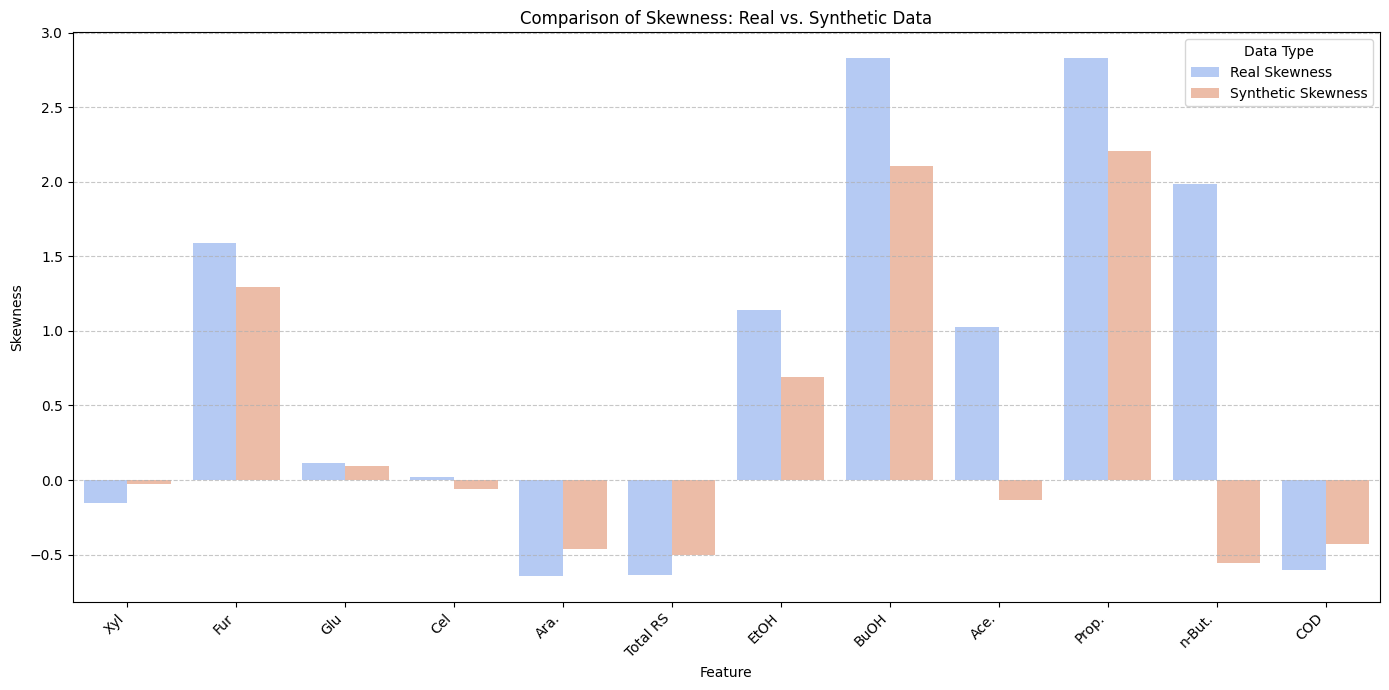

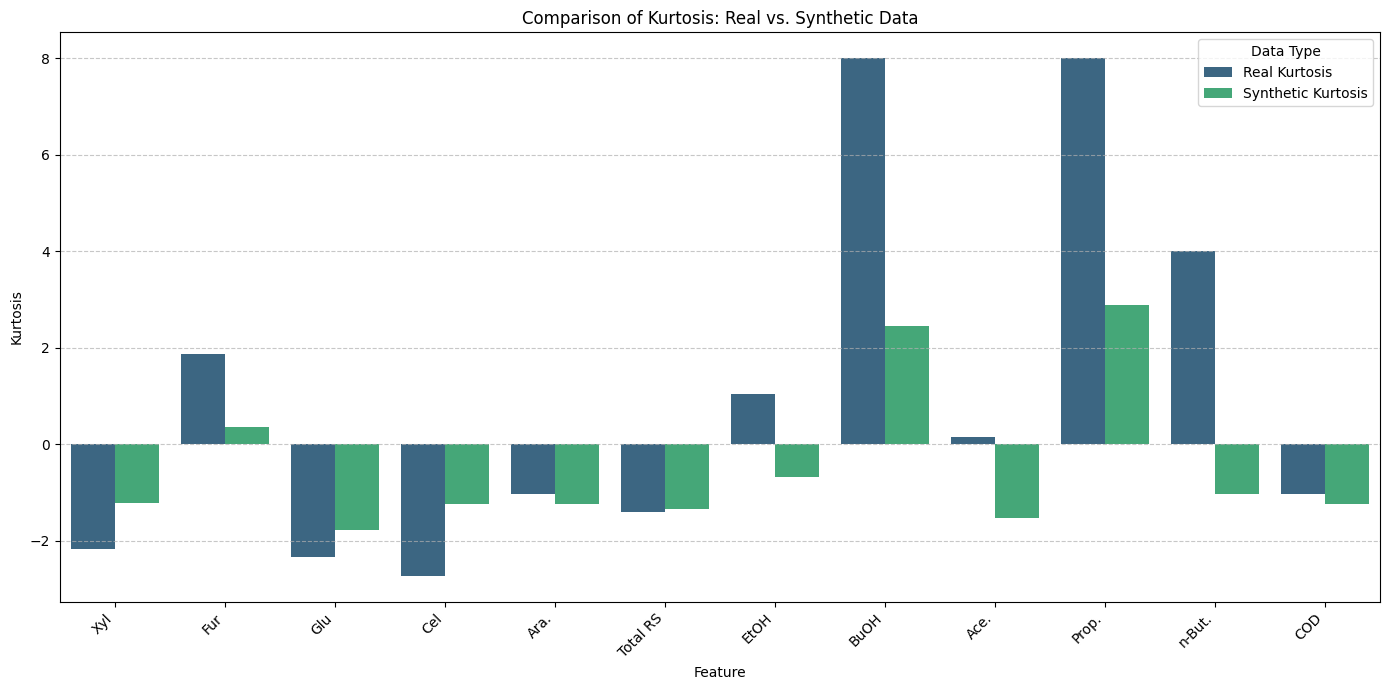

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Skewness and Kurtosis for Real and Synthetic Data
skew_real = real_data.skew(numeric_only=True)
kurt_real = real_data.kurt(numeric_only=True)
skew_synthetic = synthetic_data.skew(numeric_only=True)
kurt_synthetic = synthetic_data.kurt(numeric_only=True)

# Combine into DataFrames for plotting
skew_df = pd.DataFrame({
    'Feature': skew_real.index,
    'Real Skewness': skew_real.values,
    'Synthetic Skewness': skew_synthetic.values
})

kurt_df = pd.DataFrame({
    'Feature': kurt_real.index,
    'Real Kurtosis': kurt_real.values,
    'Synthetic Kurtosis': kurt_synthetic.values
})

# Melt DataFrames for seaborn plotting
skew_melted = skew_df.melt(id_vars='Feature', var_name='Data Type', value_name='Skewness')
kurt_melted = kurt_df.melt(id_vars='Feature', var_name='Data Type', value_name='Kurtosis')

# Plot Skewness
plt.figure(figsize=(14, 7))
sns.barplot(x='Feature', y='Skewness', hue='Data Type', data=skew_melted, palette='coolwarm')
plt.title('Comparison of Skewness: Real vs. Synthetic Data')
plt.xlabel('Feature')
plt.ylabel('Skewness')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot Kurtosis
plt.figure(figsize=(14, 7))
sns.barplot(x='Feature', y='Kurtosis', hue='Data Type', data=kurt_melted, palette='viridis')
plt.title('Comparison of Kurtosis: Real vs. Synthetic Data')
plt.xlabel('Feature')
plt.ylabel('Kurtosis')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Correlation Heatmaps: Real vs. Synthetic Data

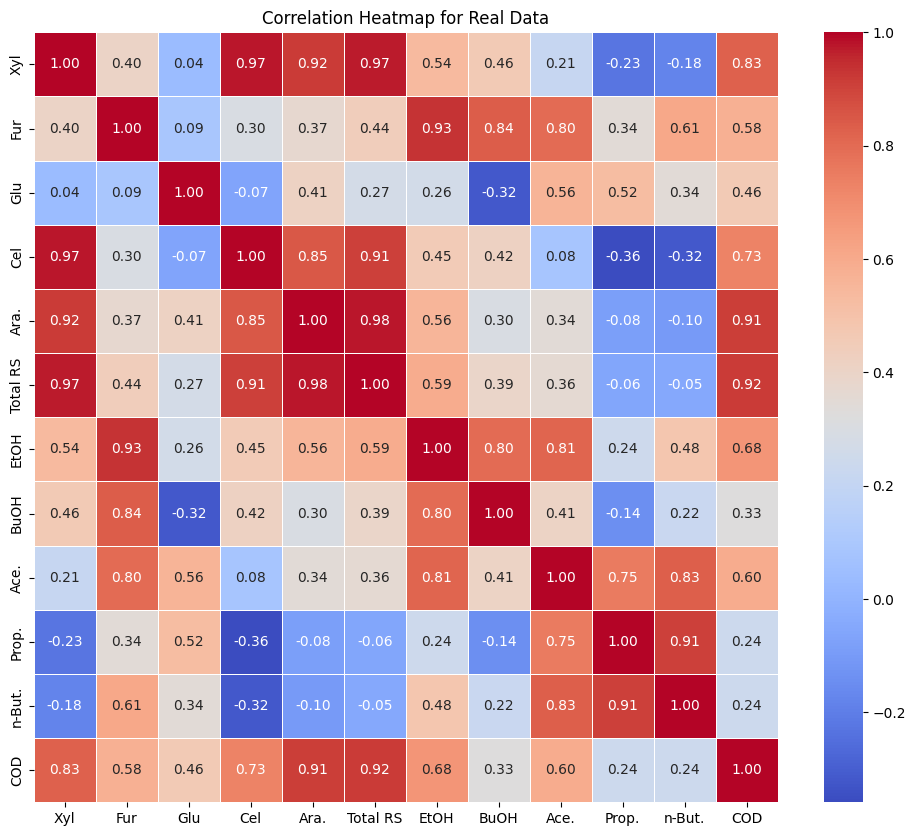

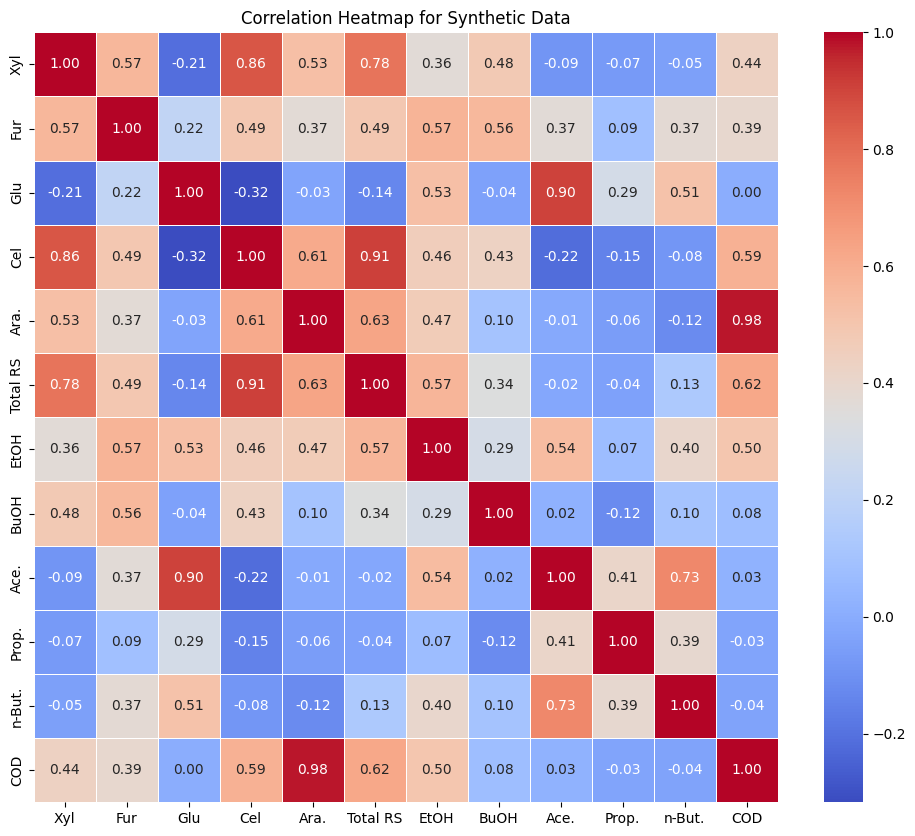

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for real data
correlation_matrix_real = real_data.corr(numeric_only=True)

# Plot the heatmap for real data
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_real, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap for Real Data')
plt.show()

# Calculate the correlation matrix for synthetic data
correlation_matrix_synthetic = synthetic_data.corr(numeric_only=True)

# Plot the heatmap for synthetic data
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_synthetic, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap for Synthetic Data')
plt.show()

(8, 14) (500, 14)


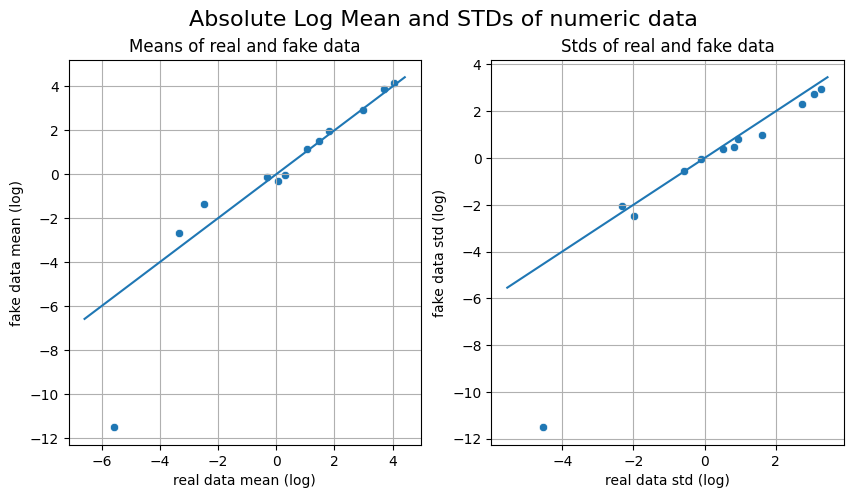

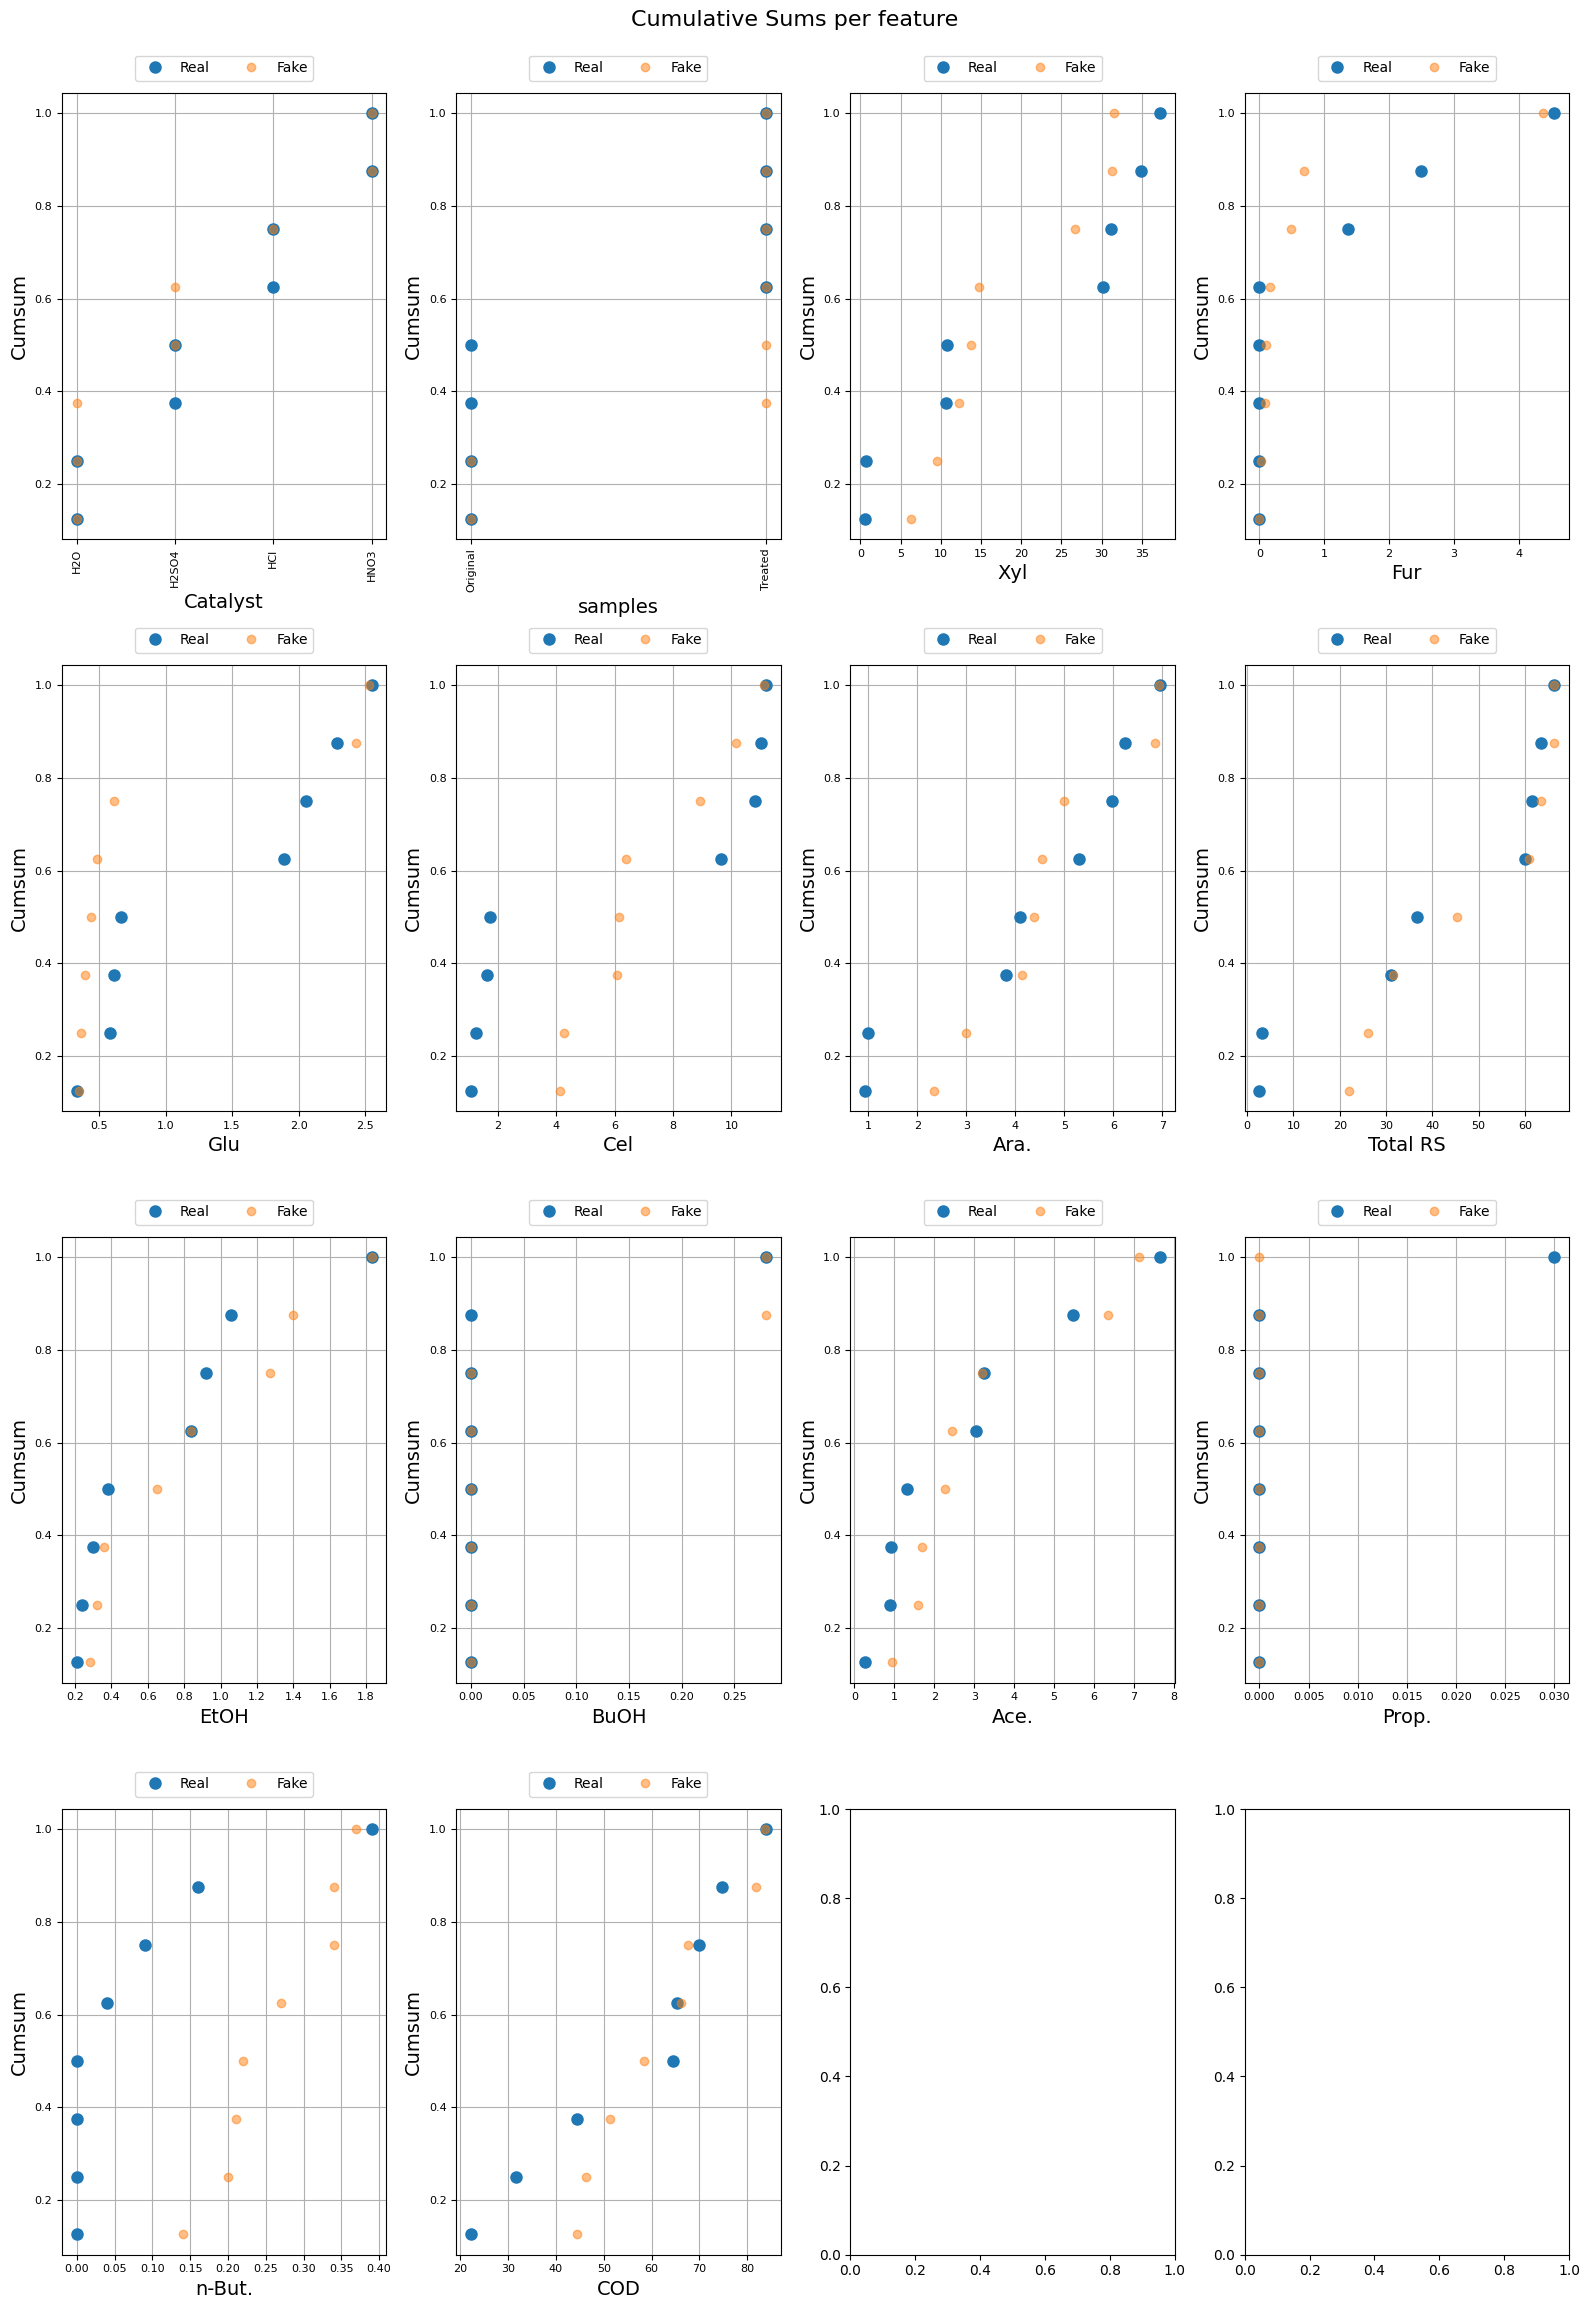

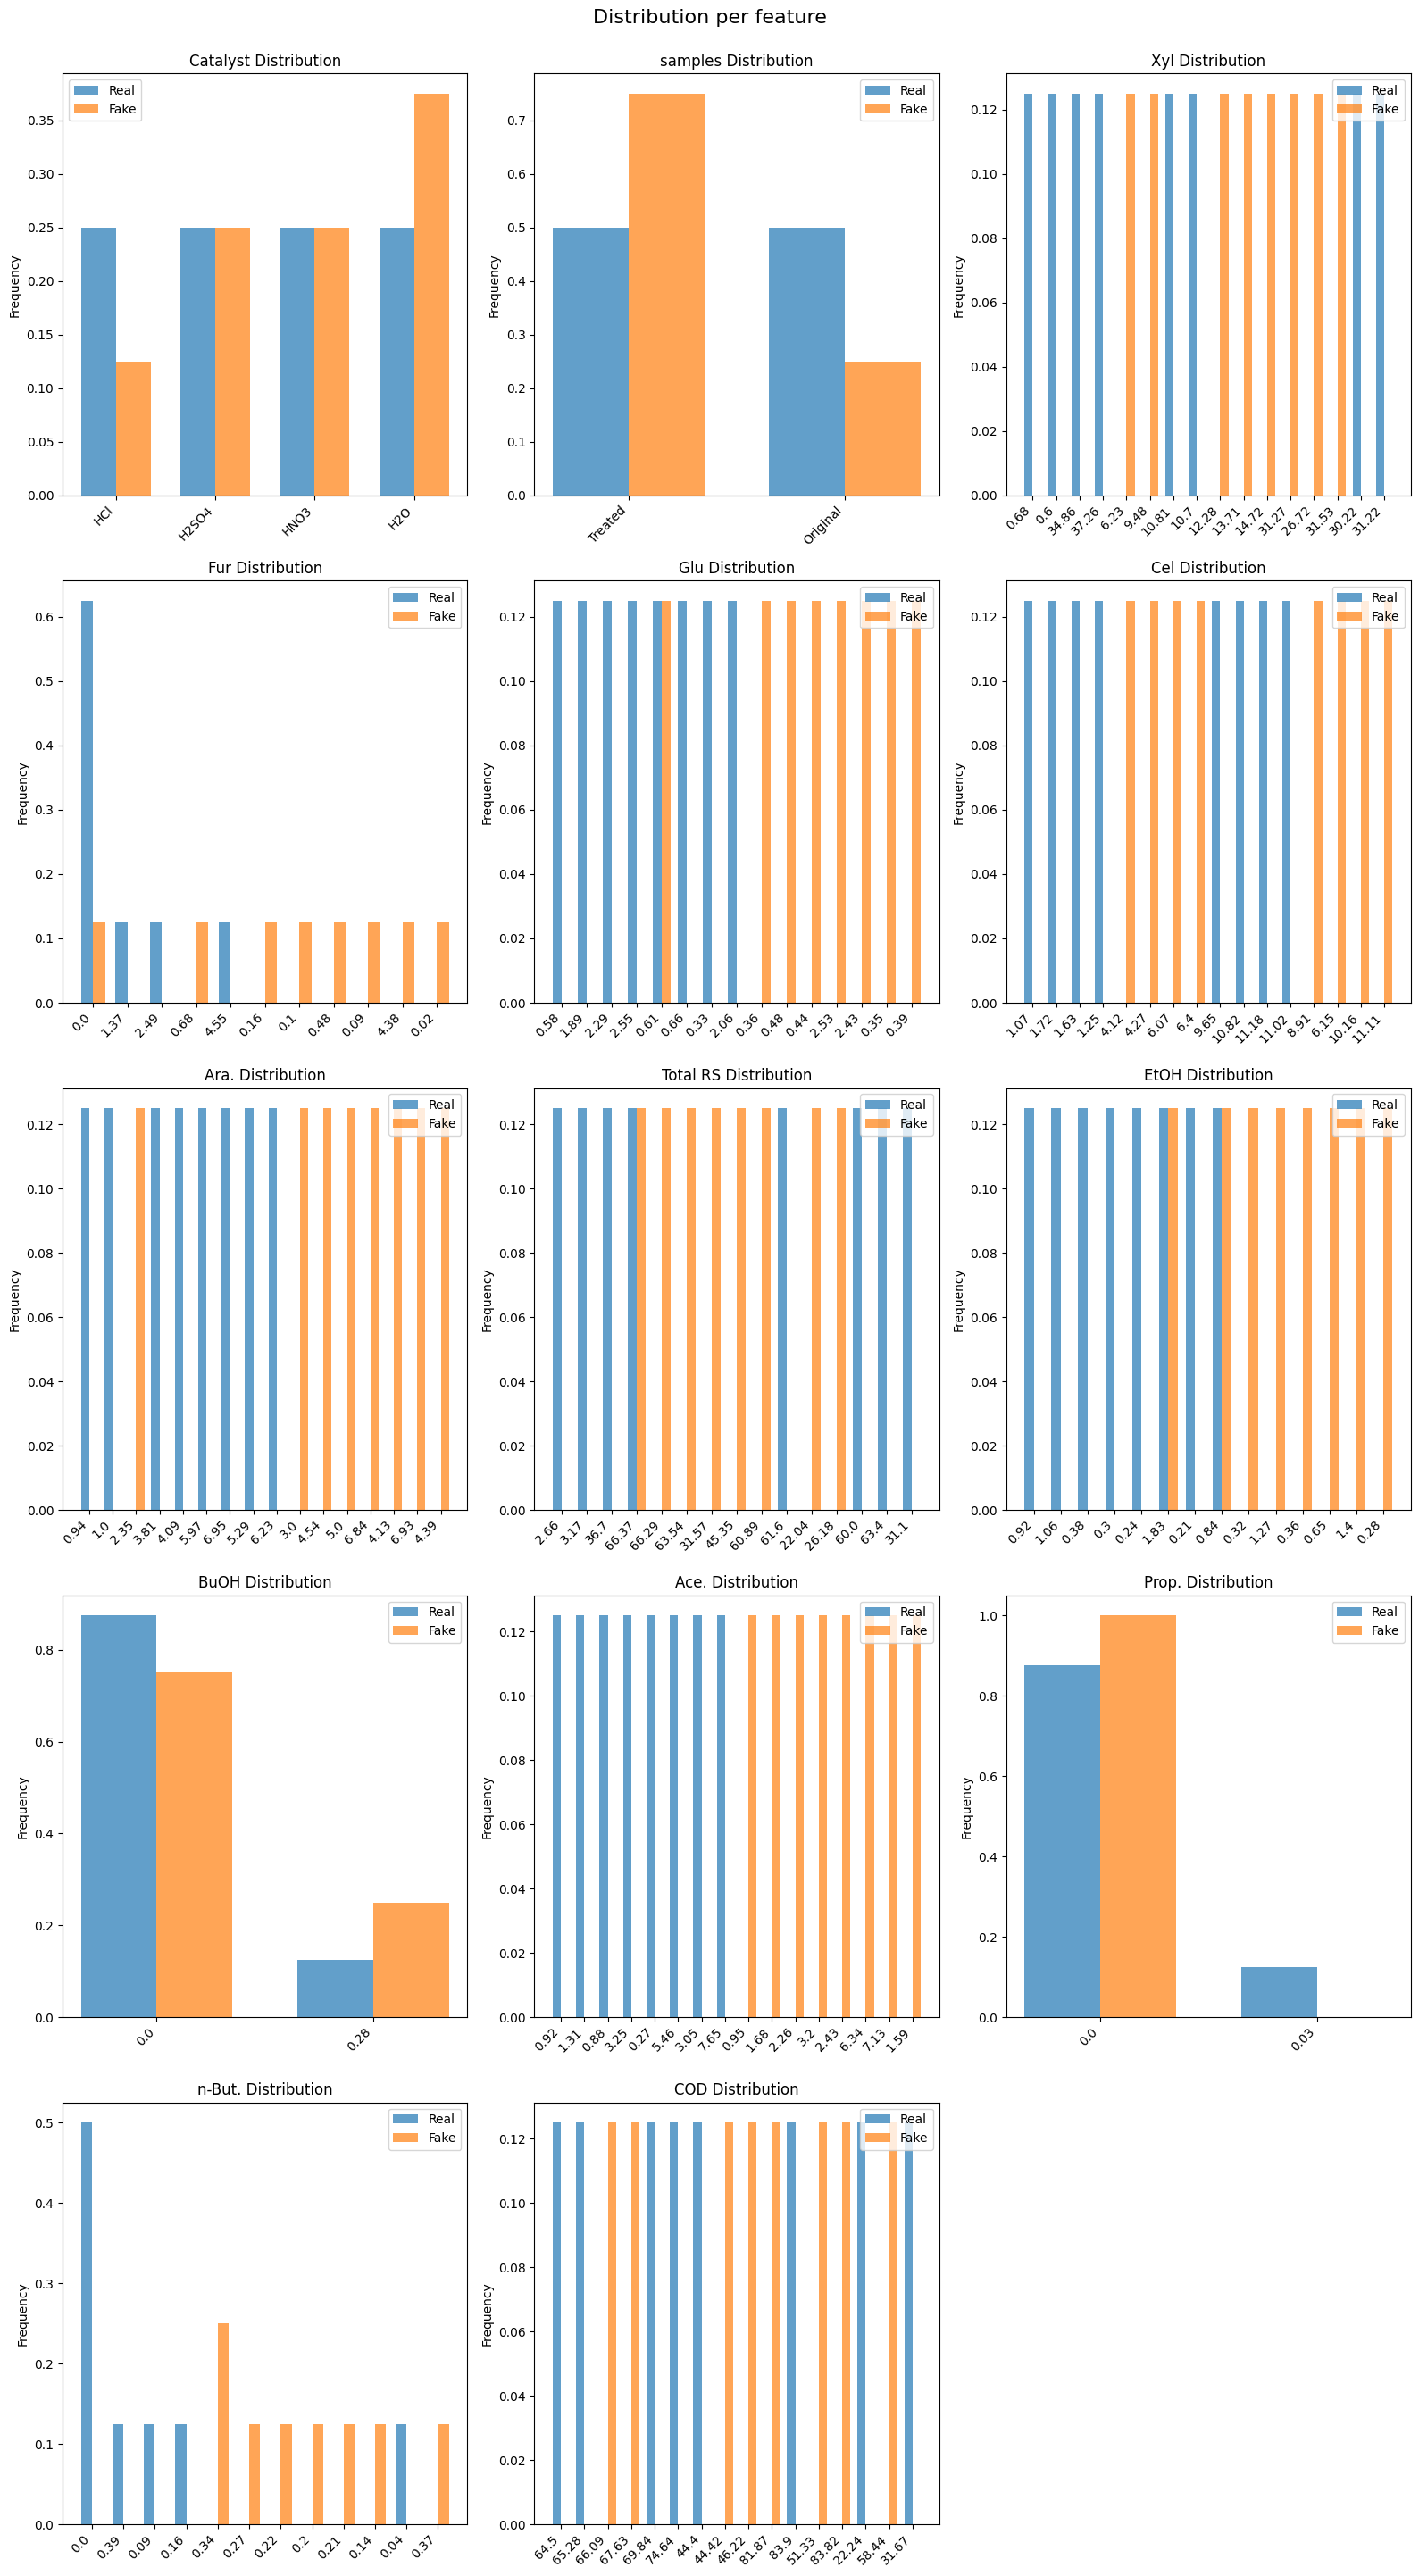

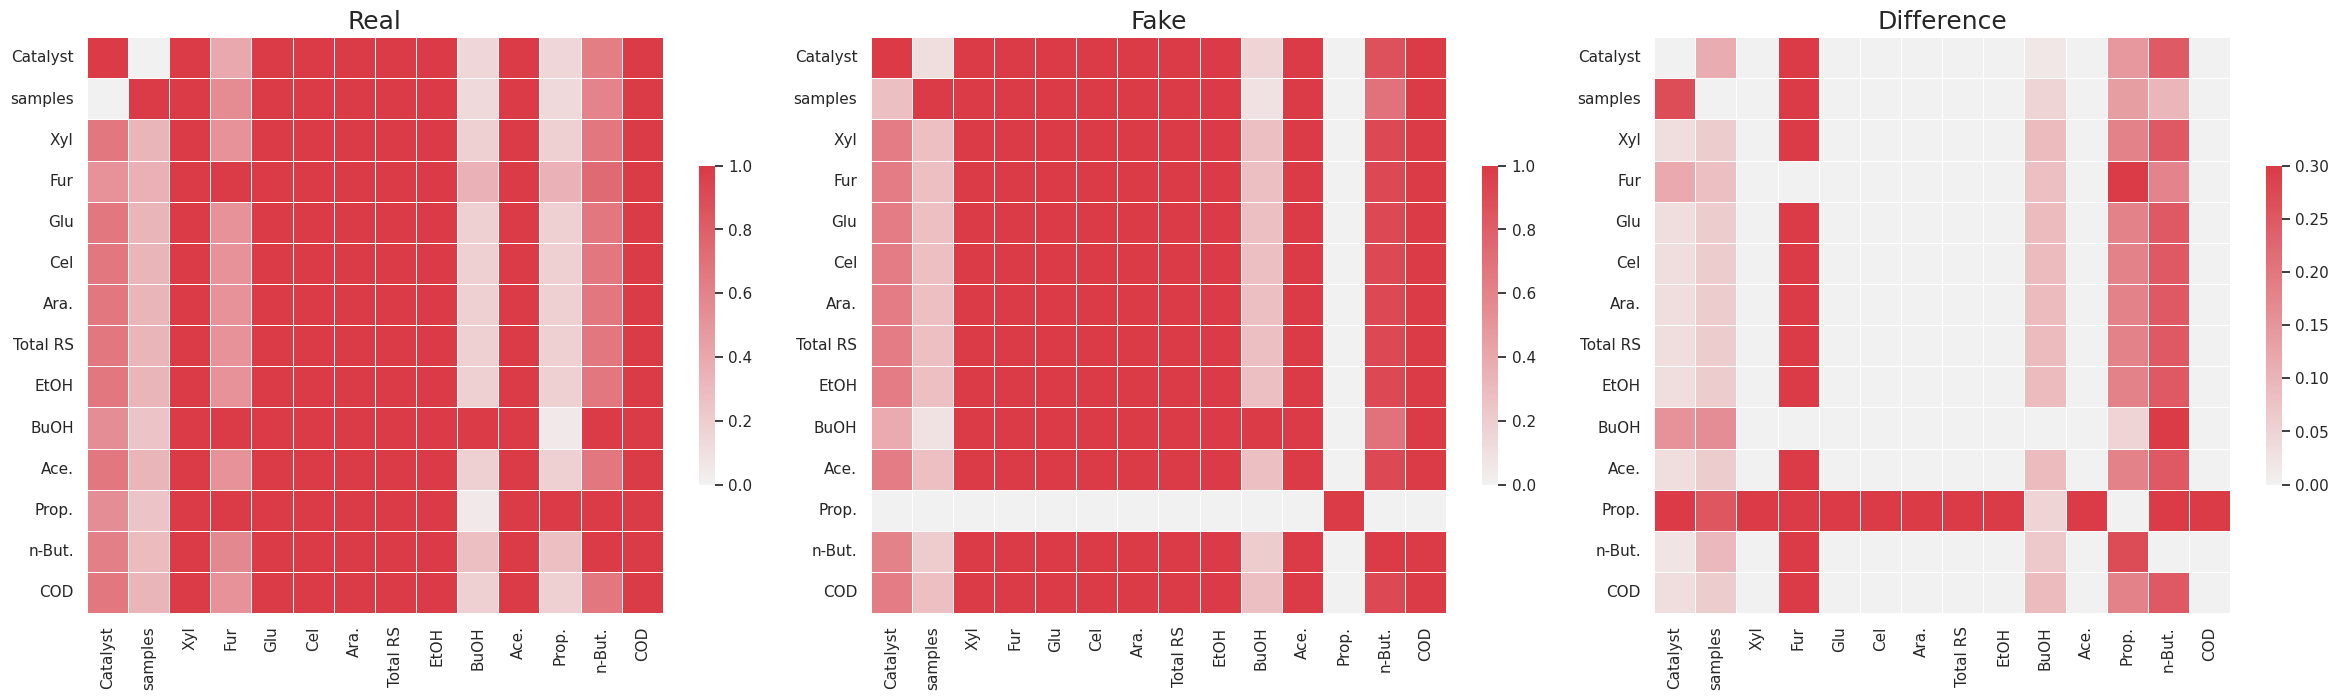

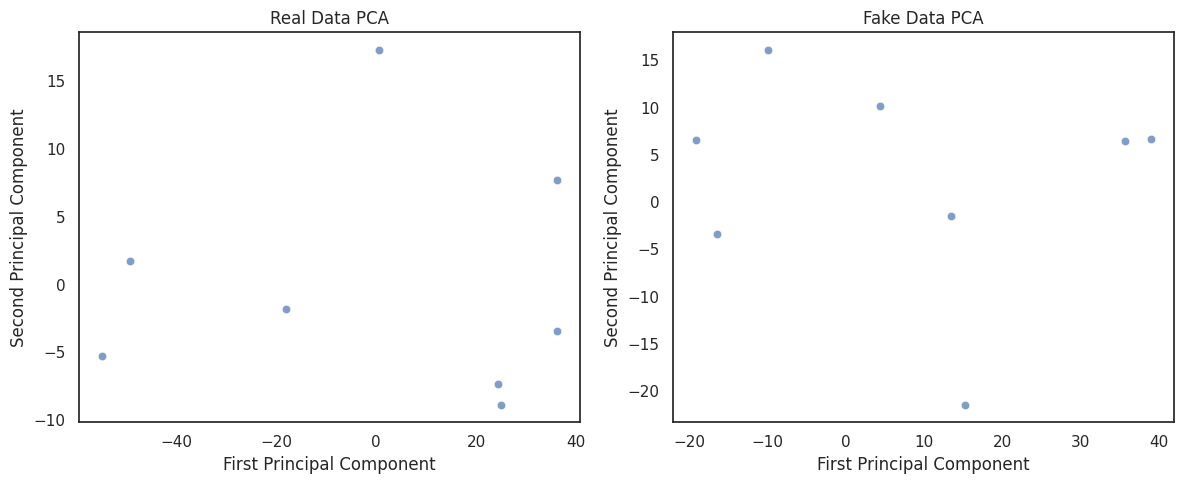

In [64]:
from table_evaluator import TableEvaluator
print(real_data.shape, synthetic_data.shape)
table_evaluator = TableEvaluator(real_data.copy(), synthetic_data.copy(), categorical_features)
table_evaluator.visual_evaluation()

### Comparing Parameter Impact on 'Total RS' in Real vs. Synthetic Data (SHAP Summary Plots)

Below are the SHAP summary plots for 'Total RS' prediction using models trained on real data and Gaussian Copula synthetic data, respectively. These plots illustrate how each feature impacts the prediction of 'Total RS' in each dataset.

SHAP Summary Plot for Real Data (impact on Total RS):


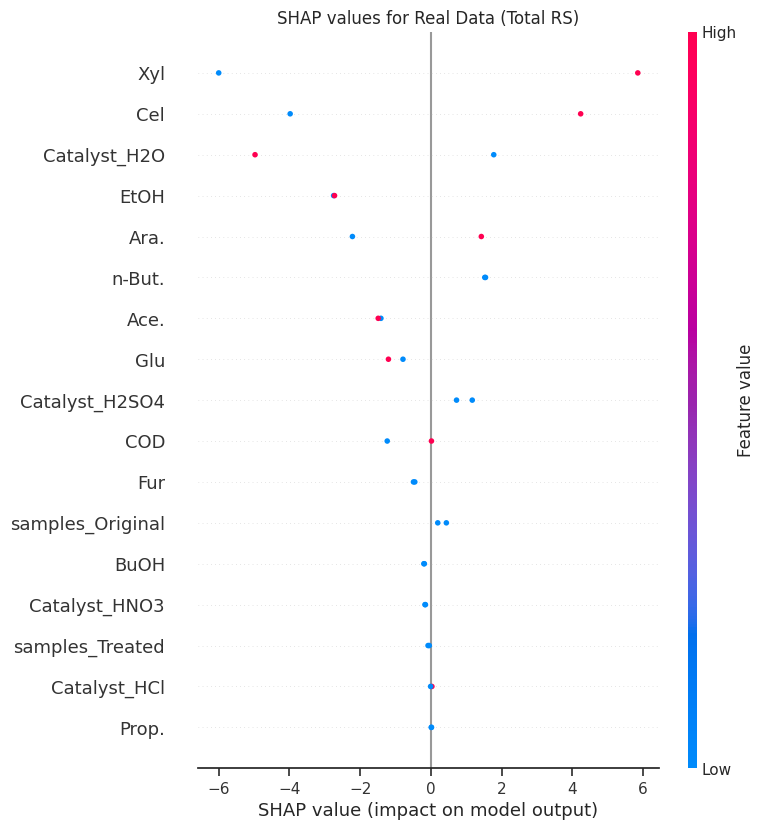


SHAP Summary Plot for Synthetic Data (impact on Total RS):


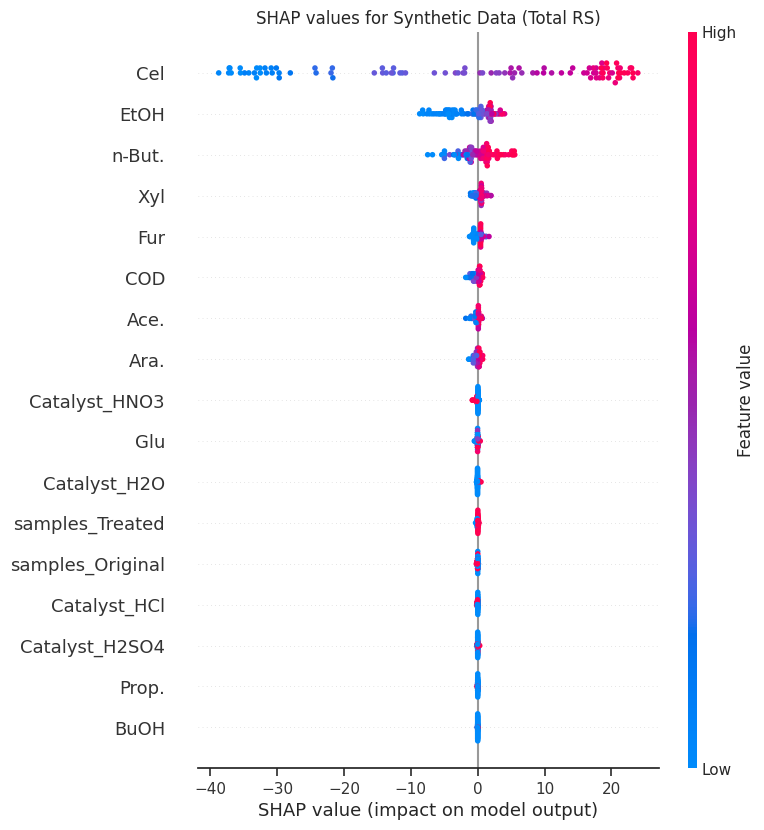

In [65]:
import shap
import matplotlib.pyplot as plt

print("SHAP Summary Plot for Real Data (impact on Total RS):")
shap.summary_plot(shap_values_real, X_real_test, plot_type="dot", show=False)
plt.title('SHAP values for Real Data (Total RS)')
plt.show()

print("\nSHAP Summary Plot for Synthetic Data (impact on Total RS):")
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title('SHAP values for Synthetic Data (Total RS)')
plt.show()

#### How to Interpret and Compare these SHAP Summary Plots:

1.  **Feature Importance:**
    *   The features are ordered by their importance (from top to bottom). The higher a feature is on the plot, the more impact it has on the 'Total RS' prediction.
    *   **Comparison:** Look at the order of features. Do the most important features in the real data also appear as the most important in the synthetic data? This indicates how well the synthetic data generator captures the primary drivers of 'Total RS'.

2.  **Impact Direction and Magnitude:**
    *   Each point represents a single observation from the dataset.
    *   The horizontal position of each point shows the SHAP value, indicating how much that feature's value shifts the prediction of 'Total RS' for that observation.
        *   Points to the right mean a positive impact (higher 'Total RS').
        *   Points to the left mean a negative impact (lower 'Total RS').
    *   The spread of the points along the x-axis shows the magnitude of the impact.
    *   **Comparison:** Compare the spread and clustering of points for each feature. For instance, if 'Xyl' has a wide spread of SHAP values in real data, does it have a similar spread in synthetic data?

3.  **Feature Value and Impact (Color):**
    *   The color of each point indicates the original value of the feature for that observation (red for high values, blue for low values).
    *   **Comparison:** Observe the relationship between feature value and impact. For example, if high 'Xyl' values (red points) tend to drive 'Total RS' higher (positive SHAP values) in the real data, does the same pattern hold true in the synthetic data? This is crucial for ensuring the synthetic data preserves the underlying causal relationships.

### Interpretation of `table_evaluator.visual_evaluation()` Results

The `table_evaluator.visual_evaluation()` function provides a comprehensive visual comparison between your real and synthetic datasets. Here's what each type of visualization typically helps you understand:

1.  **Feature Distribution Plots (Histograms/KDEs):**
    *   **Purpose:** These plots compare the individual distributions of each feature (column) between the real and synthetic data.
    *   **Interpretation:** Ideally, the shapes of the distributions for both real (blue) and synthetic (orange) data should largely overlap. If there are significant differences (e.g., synthetic data is much narrower, shifted, or has extra peaks), it indicates that the synthetic model did not accurately capture the marginal distribution of that feature.

2.  **Correlation Heatmaps:**
    *   **Purpose:** These visualize the pairwise correlations between features in both datasets.
    *   **Interpretation:** You should look for similar patterns in the correlation matrices. High positive correlations in real data should correspond to high positive correlations in synthetic data, and similarly for negative correlations. Discrepancies indicate that the synthetic model failed to preserve the relationships between pairs of features.

3.  **PCA/t-SNE Plots (Dimensionality Reduction):**
    *   **Purpose:** These reduce the high-dimensional data into 2D or 3D for visualization, allowing you to see if the overall structure and density of the synthetic data resemble the real data.
    *   **Interpretation:** The clusters or distributions of points from the synthetic data should generally align with and cover the clusters from the real data. If synthetic data points form separate clusters or are too spread out/concentrated compared to real data, it suggests a lack of fidelity in capturing the overall data manifold.

4.  **Pair Plots (Scatter Plots for Continuous Features):**
    *   **Purpose:** These show scatter plots for all continuous feature pairs, often with histograms/KDEs on the diagonal.
    *   **Interpretation:** They provide a more granular view of pairwise relationships than heatmaps. Look for similar trends, shapes, and densities in the scatter plots. For example, if two real features show a linear relationship, the synthetic features should also exhibit a similar linear trend.

5.  **Metrics Bar Charts (e.g., for Skewness, Kurtosis, etc.):**
    *   **Purpose:** These compare specific statistical metrics (like skewness or kurtosis) for each feature between the real and synthetic data.
    *   **Interpretation:** The bars for real and synthetic data for each feature should be close in height, indicating that these statistical properties are well-preserved. Large differences point to the synthetic data not accurately reflecting these higher-order statistical moments.

## 2.6 Saving and Loading
We can save the synthesizer to share with others and sample more synthetic data in the future.

In [66]:
synthesizer.save('my_synthesizer.pkl')

In [68]:
from sdv.utils import load_synthesizer

synthesizer = load_synthesizer('my_synthesizer.pkl')
synthesizer.sample(num_rows=500)

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,H2SO4,Treated,9.63,0.00,0.36,5.49,1.73,39.72,0.32,0.00,2.66,0.00,0.37,34.61
1,HNO3,Treated,16.92,0.00,0.35,6.48,4.14,11.50,0.24,0.00,0.42,0.00,0.02,47.72
2,HNO3,Treated,14.73,0.17,2.55,2.15,3.53,16.22,1.12,0.00,7.65,0.03,0.39,42.04
3,H2O,Original,3.89,1.47,2.55,1.49,2.10,14.54,1.40,0.00,7.65,0.03,0.39,41.61
4,HNO3,Original,15.74,0.00,2.10,5.83,6.62,25.97,0.71,0.00,4.51,0.00,0.06,77.34
5,HCl,Treated,16.71,0.08,2.03,2.36,2.73,5.32,0.32,0.00,4.76,0.00,0.16,34.82
6,HCl,Original,15.70,0.38,2.53,7.82,6.91,65.03,1.67,0.00,6.71,0.00,0.30,83.54
7,H2SO4,Original,13.14,0.61,1.40,7.24,6.80,62.94,1.06,0.00,5.06,0.00,0.35,83.08
8,H2SO4,Treated,26.79,0.11,0.35,8.70,5.75,64.89,0.39,0.00,1.16,0.00,0.32,69.85
9,HNO3,Treated,24.38,0.02,2.01,6.86,5.87,61.72,0.95,0.00,5.49,0.00,0.32,65.31


---

# About

The [Synthetic Data Vault Project](https://github.com/sdv-dev/SDV) was first created at MIT's Data to AI Lab in 2016. After 4 years of research and traction with enterprise, we created [DataCebo](https://datacebo.com/) in 2020 with the goal of growing the project. Today, DataCebo is the proud developer of SDV, the largest ecosystem for tabular synthetic data generation & evaluation.


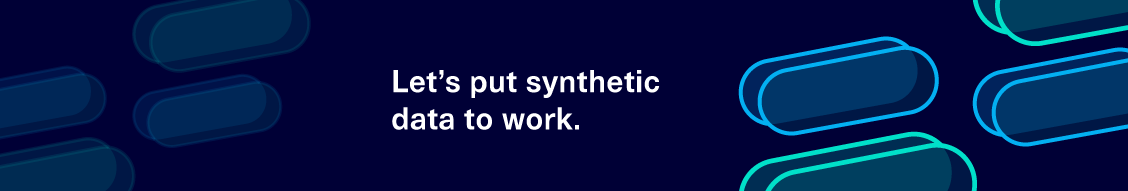